In [1]:
# useful to autoreload the module without restarting the kernel
%load_ext autoreload
%autoreload 2

In [2]:
from mppi import Parsers as P
from mppi.Utilities import LRoptics as LR, NLoptics as NL, Utils as U
import matplotlib.pyplot as plt
from mppi.Utilities import Constants as C
from mppi.Utilities import FourierTransform as FT
import numpy as np
import os

# Analysis of the Optics modules

This notebook describes the various modules of the package built in order to extract both the linear and non-linear optical properties of a system
from the knowledge of the real-time polarization.

## Linear response analysis

We show how to compute the linear response starting from the real-time polarization.

To this aim we load the ndb produced by yambo_nl for LiF in the linear response regime

In [3]:
file = 'YamboParser_test/nl_results/LiF-delta_pulse/ndb.Nonlinear'

In [4]:
data = P.YamboNLDBParser(file)

Parse file : YamboParser_test/nl_results/LiF-delta_pulse/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [5]:
time_fs = data.get_time() # in fs
time_au = data.IO_TIME_points
P_t = data.Polarization[0]
efield = data.Efield[0]
t_initial_au=efield["initial_time"]
t_initial_fs = t_initial_au/C.FsToAu

The module can deal with both time variables expressed in fs or in au.

The damp_ft function applies a damping in the time domain to produce a spread in the frequency domain and avoid 
spurious oscillations of the optical quantities.
The damping eta is expressed in eV

In [6]:
P_damped = U.damp_ft(P_t,time_fs,t_initial=t_initial_fs,eta=0.1,time_units='fs')

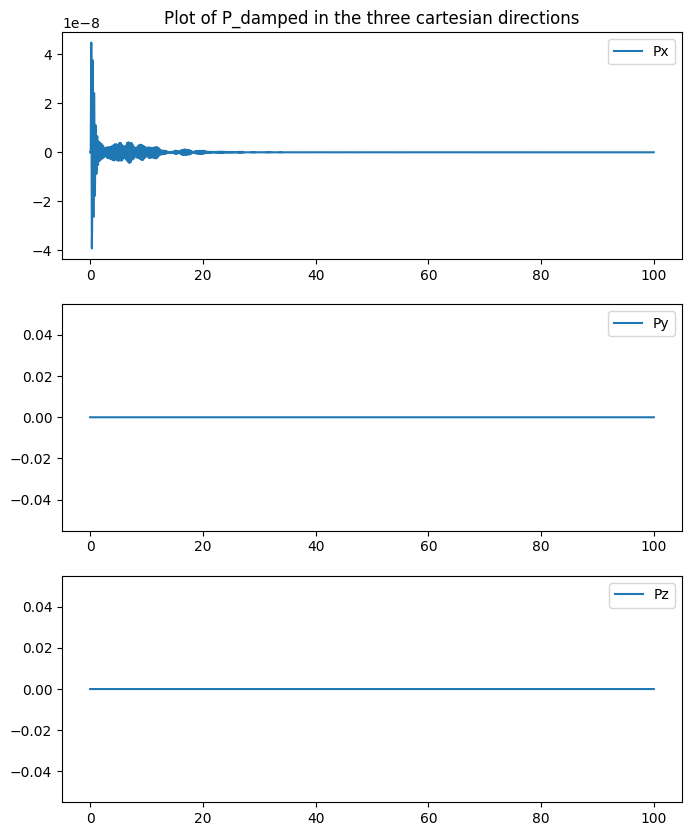

In [7]:
U.Plot_3dArray(time_fs,P_damped,label='P_damped')

The linear response is computed by the Linear_response function of the module

In [8]:
energy,chi = LR.Linear_Response(time_fs,P_t,efield=efield,eta=0.1,time_units='fs')

Time units = fs. Rescaled to au


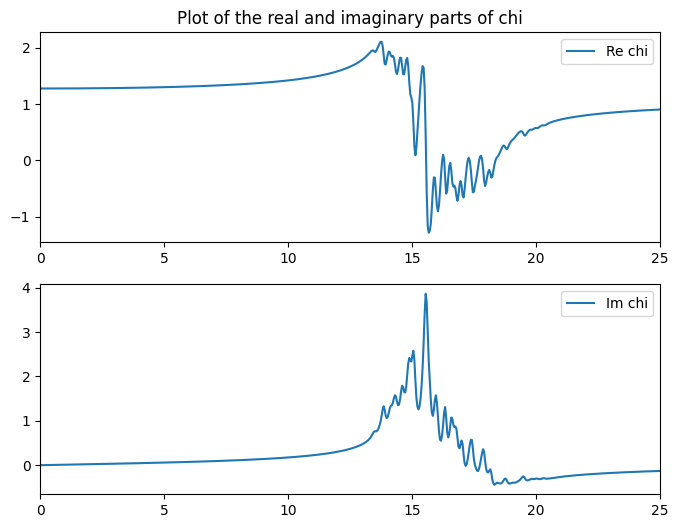

In [9]:
U.Plot_ComplexArray(energy,chi,xlim=(0,25),label='chi')

## Non-linear analysis for a sine-shaped pulse

We analyze the extraction of the non-linear response from a bunch of monocromatic sine-shaped fields

In [98]:
file = 'YamboParser_test/nl_results/LiF-sine_pulse-time_200fs-step_10as/ndb.Nonlinear'
data = P.YamboNLDBParser(file)

Parse file : YamboParser_test/nl_results/LiF-sine_pulse-time_200fs-step_10as/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [99]:
nl = NL.Xn_from_sine(data,Trange=[-1,-1])

Time range of the simulation (in au): 0.0 - 8268.274667312273
Time range of the simulation (in fs): 0.0 - 200.00000162820604
Number of frequencies: 50
Frequency range of the field (in Hartree): 0.18374663009599138 - 0.9040334200722775
Frequency range of the field (in eV): 5.000000477741239 - 24.600002350486893
Damping factor: 0.003674932601919828 Hartree 0.10000000955482478 eV
Dephasing time: 3265.3660079999995 au 78.98542721355673 fs


In [87]:
iT = nl.set_time_sampling(0)
iT

(19917, 20000)

In [88]:
nl.time[iT[0]]/C.FsToAu,nl.time[iT[1]]/C.FsToAu

(np.float64(199.170001621449), np.float64(200.00000162820604))

In [89]:
nl.eval_harmonic_fit(0)

(array([7.21887821e-13, 0.00000000e+00, 0.00000000e+00]),
 array([2.95772104e-06, 0.00000000e+00, 0.00000000e+00]),
 array([-0.80104392,  0.        ,  0.        ]))

In [93]:
p_w = nl.eval_harm_pol_w()
p_w.shape

(50, 3)

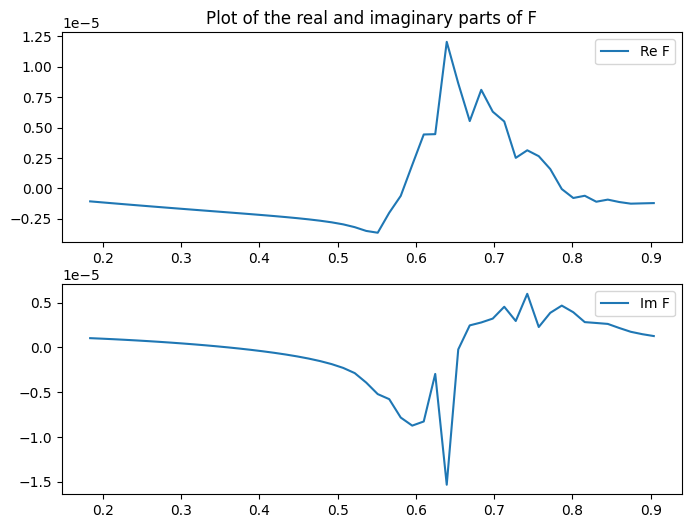

In [97]:
U.Plot_ComplexArray(nl.fields_freqs,p_w[:,0])

In [102]:
e_w = nl.eval_Efield_w()
e_w.shape

(50,)

In [104]:
chi = p_w/e_w
chi.shape

ValueError: operands could not be broadcast together with shapes (50,3) (50,) 

## Non-linear analysis for a sine-shaped pulse

We analyze the non-linear response starting from the real-time polarization.

To this aim we load the ndb produced by yambo_nl for LiF for a (bunch of) sine-shaped pulses

In [250]:
file = 'YamboParser_test/nl_results/LiF-sine_pulse/ndb.Nonlinear'

In [251]:
data = P.YamboNLDBParser(file)

Parse file : YamboParser_test/nl_results/LiF-sine_pulse/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [252]:
data.NL_damping

masked_array(data=0.00367493,
             mask=False,
       fill_value=1e+20)

In [253]:
0.1/C.HaToeV

0.0036749322507864906

In [254]:
SIG = NL.Xn_from_sine(data,X_order=1,solver='lstsq',nsamp=-1,debug_mode=False) #,T_range=[10*C.FsToAu,200*C.FsToAu]
#,T_range=[50.0*C.FsToAu,100.0*C.FsToAu]
print(SIG)


 * * *  Xn from signal class  * * * 

Max time: 4134.137333656136
Time step : 2.0670686668280682
Type Efield    : SIN
Number of runs   : 50
Max harmonic order   : 1
Solver           : lstsq
Frequency range: [0.18374663009599138,0.9040334200722775] [au] 



In [255]:
out = SIG.perform_analysis()
freqs,chi = SIG.output_analysis(out)
#chi.shape

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 1660.20it/s]

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic order   : 1
# Solver               : lstsq
# Sampling points      : 3
# Start sampling time  : 99.17286735452048 [fs] 

# Field details:# Type field            SIN
# Field intensity       1.553659979614254e-07
# Field versor          [1. 0. 0.]
# Analysis details:# Max harmonic order   : 1
# Solver               : lstsq
# Sampling points      : 3
# Start sampling time  : 99.17286735452048 [fs] 



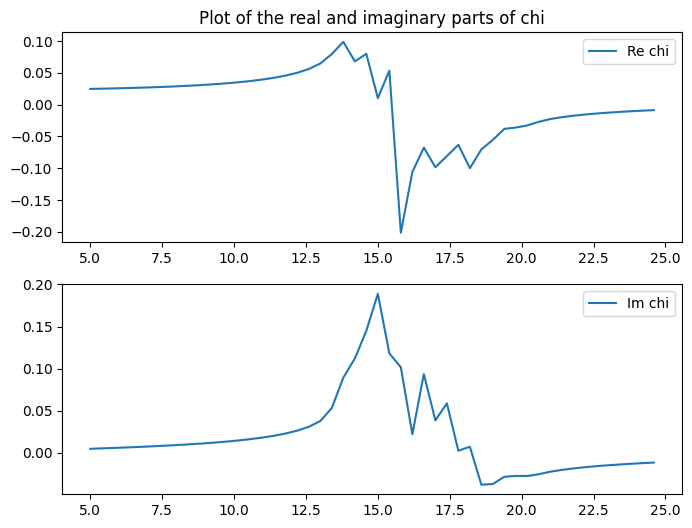

In [256]:
U.Plot_ComplexArray(C.HaToeV*freqs,chi[1,:,0],label='chi') #,xlim=(0,1)

In [286]:
recon = SIG.reconstruct_signal(chi).T
time,P_r = recon[0],recon[1]
recon.shape

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 3855.98it/s]


(4, 2001)

In [287]:
P_r.shape

(2001,)

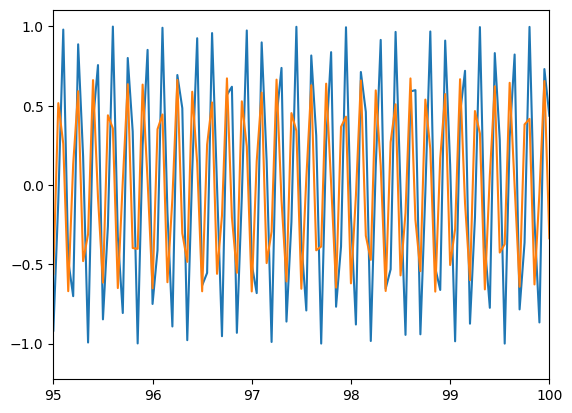

In [281]:
plt.plot(time,P_r/max(P_r),)
plt.xlim(95,100)
plt.plot(data.get_time(),data.Polarization[-1][0]/max(data.Polarization[-1][0]))

In [233]:
data.Polarization[0].shape

(3, 2001)